## Importing and cleaning the files

### Data Cleaning and Pre-Processing

In [2]:
import zipfile
import os

zip_path = 'Yelp-Photos.zip'
extract_dir = 'yelp_photos'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [10]:
import tarfile
import os

# Path to your tar file
tar_path = r'./yelp_photos/yelp photos/yelp_photos.tar'  # or .tar.gz if compressed

# Directory to extract to
extract_dir = r'yelp_photos/yelp_photos_unzipped'

os.makedirs(extract_dir, exist_ok=True)

# Open and extract
with tarfile.open(tar_path, 'r:*') as tar:
    tar.extractall(path=extract_dir)

print("Extraction completed.")

# List some extracted files
file_list = os.listdir(extract_dir)
print(f"Total files found: {len(file_list)}")
print("Sample files:")
print(file_list[:20])

C:\Users\User\AppData\Local\Temp\ipykernel_40216\3747300362.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Extraction completed.
Total files found: 3
Sample files:
['Dataset_User_Agreement.pdf', 'photos', 'photos.json']


In [13]:
import json

In [17]:
with open('yelp_photos/yelp_photos_unzipped/photos.json', 'r') as f:
    content = f.read()
print(content[:500])  # print first 500 chars to check format

{"photo_id": "zsvj7vloL4L5jhYyPIuVwg", "business_id": "Nk-SJhPlDBkAZvfsADtccA", "caption": "Nice rock artwork everywhere and craploads of taps.", "label": "inside"}
{"photo_id": "HCUdRJHHm_e0OCTlZetGLg", "business_id": "yVZtL5MmrpiivyCIrVkGgA", "caption": "", "label": "outside"}
{"photo_id": "vkr8T0scuJmGVvN2HJelEA", "business_id": "_ab50qdWOk0DdB6XOrBitw", "caption": "oyster shooter", "label": "drink"}
{"photo_id": "pve7D6NUrafHW3EAORubyw", "business_id": "SZU9c8V2GuREDN5KgyHFJw", "caption": "S


### As we have imported the photos.json we can see the classes we found - inside, outside, food, menu, drink

### Now we will Validate and cleaning up the corrupt images

In [23]:
import os
import json
from PIL import Image, UnidentifiedImageError

# Load JSON labels
json_path = 'yelp_photos/yelp_photos_unzipped/photos.json'
try:
    with open(json_path, 'r') as f:
        photo_labels = json.load(f)
except json.JSONDecodeError:
    photo_labels = []
    with open(json_path, 'r') as f:
        for line in f:
            if line.strip():
                photo_labels.append(json.loads(line))

print(f"Loaded {len(photo_labels)} label entries.")

photos_folder = 'yelp_photos/yelp_photos_unzipped/photos'
possible_ext = ['.jpg', '.jpeg', '.png', '.gif']

skipped_files = []

for item in photo_labels:
    photo_id = item['photo_id']
    
    img_path = None
    for ext in possible_ext:
        tentative_path = os.path.join(photos_folder, f"{photo_id}{ext}")
        if os.path.exists(tentative_path):
            img_path = tentative_path
            break
    
    if img_path is None:
        print(f"Warning: No image file found for photo_id {photo_id}")
        continue
    
    try:
        with Image.open(img_path) as img:
            img.verify()  # Verify image integrity without loading all pixels
    except (UnidentifiedImageError, IOError):
        print(f"Warning: Cannot open image {img_path}, deleting.")
        skipped_files.append(img_path)

# Delete all unreadable image files
for file_path in skipped_files:
    try:
        os.remove(file_path)
        print(f"Deleted file: {file_path}")
    except Exception as e:
        print(f"Failed to delete {file_path}: {e}")

print(f"Deleted {len(skipped_files)} unreadable images.")

Loaded 200100 label entries.
Deleted file: yelp_photos/yelp_photos_unzipped/photos\ydm3g1wUWSxJnMPgHk2JhQ.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\JGpfPj8VEvnq1B-Xqr3w-A.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\bf3ymV0YgP7B6rEoriaU2w.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\juDNZOOnkgG3QINFrulsAg.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\9X4YPM8nYFjf7hY8xUdc6Q.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\N6hL8FQ84A2DznF2S2Lp7g.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\pY32hIagdxrL4Nsi959EQg.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\cNkUV0sInfh_Py5PP8SHtQ.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\Pk87_8Yndygr4LRUD_H7Hg.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\ke4ohxa93GJz0KH9H2kwsQ.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\rLafN9k3_AF5lZU0cs3LZg.jpg
Deleted file: yelp_photos/yelp_photos_unzipped/photos\-YAvSvGUs2ugiJUvIRO6Jw.jpg

### Here we can see that 106 images are unreadable hence it has been deleted

## Resizing the image to fixed size and ensuring the photos to 3 color channel 'RGB'

In [26]:
import os
from PIL import Image

# Input folder with cleaned images
input_folder = r'yelp_photos/yelp_photos_unzipped/photos'

# Output folder where resized images will be saved
output_folder = r'yelp_photos/yelp_photos_resized'
os.makedirs(output_folder, exist_ok=True)

target_size = (224, 224)  # width, height

for filename in os.listdir(input_folder):
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)
    
    try:
        with Image.open(input_path) as img:
            img = img.convert('RGB')  # Ensure 3-channel RGB
            img = img.resize(target_size)
            img.save(output_path)
    except Exception as e:
        print(f"Failed to process {filename}: {e}")

print(f"Resizing completed. Resized images saved to: {output_folder}")

Resizing completed. Resized images saved to: yelp_photos/yelp_photos_resized


## Hence all the images have been resized so next we will separate the images according to the classes for labelling

In [37]:
import json
import os
import shutil

# Paths
json_path = 'yelp_photos/yelp_photos_unzipped/photos.json'
image_folder = 'yelp_photos/yelp_photos_resized'
output_folder = 'yelp_photos/labeled_photos'  # output folder for sorted images by label

# Create output folder if not exists
os.makedirs(output_folder, exist_ok=True)

# Load JSON lines
with open(json_path, 'r') as f:
    lines = f.readlines()

photo_data = [json.loads(line) for line in lines]

# Process each photo
count_copied = 0
for entry in photo_data:
    photo_id = entry.get('photo_id')
    label = entry.get('label')

    # Skip if label is missing
    if not label:
        continue

    # Construct filenames
    filename_jpg = photo_id + '.jpg'
    filename_png = photo_id + '.png'

    # Check file existence and source path
    src_path = None
    if os.path.exists(os.path.join(image_folder, filename_jpg)):
        src_path = os.path.join(image_folder, filename_jpg)
    elif os.path.exists(os.path.join(image_folder, filename_png)):
        src_path = os.path.join(image_folder, filename_png)

    if src_path:
        # Create label folder inside output folder
        label_folder = os.path.join(output_folder, label)
        os.makedirs(label_folder, exist_ok=True)

        # Destination path
        dest_path = os.path.join(label_folder, os.path.basename(src_path))

        # Copy the image to the label folder
        shutil.copy2(src_path, dest_path)
        count_copied += 1

print(f"Copied {count_copied} images into labeled folders inside '{output_folder}'")

Copied 199994 images into labeled folders inside 'yelp_photos/labeled_photos'


## Understand Class Distribution

In [45]:
import os

data_dir = 'yelp_photos/labeled_photos'

label_counts = {}
for label in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label)
    if os.path.isdir(label_folder):
        count = len(os.listdir(label_folder))
        label_counts[label] = count

print("Number of images per label:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Number of images per label:
drink: 15670
food: 108047
inside: 56030
menu: 1678
outside: 18569


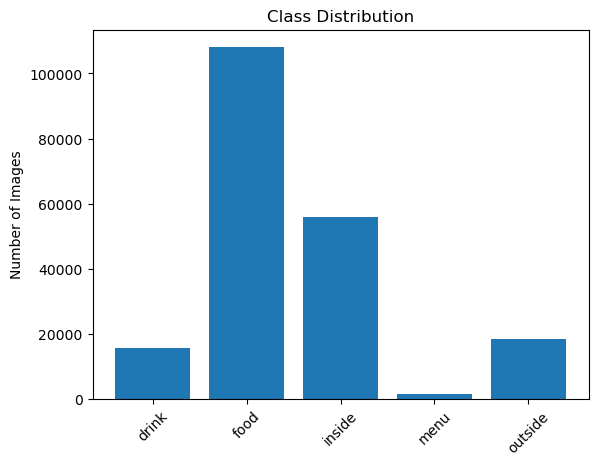

In [47]:
import matplotlib.pyplot as plt

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.show()

## Check Image Size for Any Outliers

In [49]:
from PIL import Image
import numpy as np

image_sizes = []

for label in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label)
    for img_file in os.listdir(label_folder):
        img_path = os.path.join(label_folder, img_file)
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)  # (width, height)
        except:
            print(f"Could not open {img_path}")

# Convert to numpy array for stats
sizes_np = np.array(image_sizes)

print(f"Unique image sizes found: {np.unique(sizes_np, axis=0)}")
print(f"Mean width: {np.mean(sizes_np[:,0])}, Mean height: {np.mean(sizes_np[:,1])}")

Unique image sizes found: [[224 224]]
Mean width: 224.0, Mean height: 224.0


# EDA

### Class Distribution

In [53]:
import os

data_dir = './yelp_photos/labeled_photos'

label_counts = {}
for label in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label)
    if os.path.isdir(label_folder):
        count = len(os.listdir(label_folder))
        label_counts[label] = count

print("Number of images per label:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Number of images per label:
drink: 15670
food: 108047
inside: 56030
menu: 1678
outside: 18569


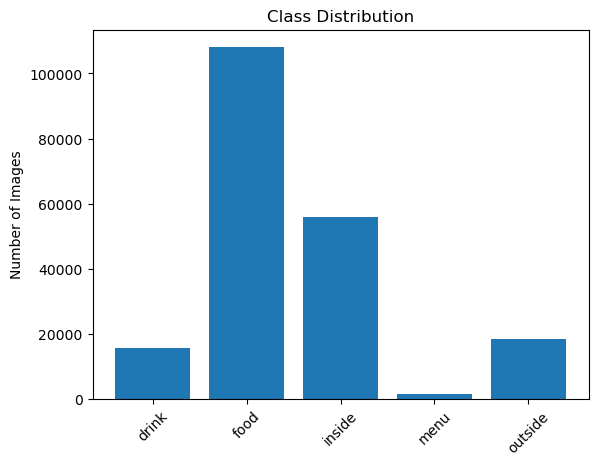

In [55]:
import matplotlib.pyplot as plt

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.show()

### Here we can see that there is a lot of class imbalance

### Downsampling the food to 20,000

In [61]:
import os
import random
import shutil

# Downsampling 'food' to 20k samples (from 108k)
majority_label = 'food'
target_count = 20000

src_folder = os.path.join('./yelp_photos/labeled_photos', majority_label)
dst_folder = os.path.join('./yelp_photos/balanced_labeled_photos', majority_label)
os.makedirs(dst_folder, exist_ok=True)

all_files = os.listdir(src_folder)
print(f"Original {majority_label} count: {len(all_files)}")

sampled_files = random.sample(all_files, target_count)

for file in sampled_files:
    shutil.copy2(os.path.join(src_folder, file), os.path.join(dst_folder, file))
print(f"Downsampled {majority_label} to {target_count} samples.")

Original food count: 108047
Downsampled food to 20000 samples.


### Downsampling the inside to 20,000

In [64]:
# Downsample 'inside' class to 20k samples
majority_label = 'inside'
target_count = 20000

src_folder = os.path.join('./yelp_photos/labeled_photos', majority_label)
dst_folder = os.path.join('./yelp_photos/balanced_labeled_photos', majority_label)
os.makedirs(dst_folder, exist_ok=True)

all_files = os.listdir(src_folder)
print(f"Original {majority_label} count: {len(all_files)}")

sampled_files = random.sample(all_files, target_count)

for file in sampled_files:
    shutil.copy2(os.path.join(src_folder, file), os.path.join(dst_folder, file))
print(f"Downsampled {majority_label} to {target_count} samples.")

Original inside count: 56030
Downsampled inside to 20000 samples.


### For Minority Classes like drink, outside and menu - Upsampling and Augmentation
- For drink, outside, and menu classes, we will augment the data to make their sizes more comparable.
- Data Augmentation: Using libraries like PIL or Albumentations, we can augment the images for these minority classes.

In [67]:
from PIL import Image, ImageEnhance
import random
import os
import shutil

def augment_image(image_path, augmented_folder):
    # Open image
    img = Image.open(image_path)
    
    # Apply some augmentations
    # Rotate image randomly between -15 to +15 degrees
    img = img.rotate(random.randint(-15, 15))

    # Flip image randomly
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Random zoom (crop a random section and resize back)
    width, height = img.size
    crop_width = random.randint(int(0.8 * width), width)
    crop_height = random.randint(int(0.8 * height), height)
    img = img.crop((0, 0, crop_width, crop_height)).resize((width, height))

    # Save the augmented image
    augmented_image_path = os.path.join(augmented_folder, os.path.basename(image_path))
    img.save(augmented_image_path)

def augment_class_images(label_name, target_count, source_folder, augmented_folder):
    os.makedirs(augmented_folder, exist_ok=True)
    
    # Load existing images in the class folder
    all_files = os.listdir(source_folder)
    
    # We will augment images until we reach the target count
    augmented_files = []
    while len(augmented_files) < target_count:
        for file in all_files:
            image_path = os.path.join(source_folder, file)
            if len(augmented_files) >= target_count:
                break
            augment_image(image_path, augmented_folder)
            augmented_files.append(file)
    
    print(f"Augmented {label_name} to {len(augmented_files)} samples.")

# Augment 'drink' class to reach 20k samples
augment_class_images('drink', 20000, os.path.join('./yelp_photos/labeled_photos', 'drink'), './yelp_photos/balanced_labeled_photos/drink')

# Augment 'outside' class to reach 20k samples
augment_class_images('outside', 20000, os.path.join('./yelp_photos/labeled_photos', 'outside'), './yelp_photos/balanced_labeled_photos/outside')

# Augment 'menu' class to reach 20k samples
augment_class_images('menu', 20000, os.path.join('./yelp_photos/labeled_photos', 'menu'), './yelp_photos/balanced_labeled_photos/menu')

Augmented drink to 20000 samples.
Augmented outside to 20000 samples.
Augmented menu to 20000 samples.


### Explanation of the Augmentation Process:
- Rotation: Randomly rotate images between -15 and +15 degrees.
- Flip: Randomly flip images horizontally.
- Zoom/Crop: Randomly crop part of the image and resize it back to the original size.
- This will help increase diverse photos in our minority class without creating exact duplicates.

### Class Distribution Plot
We’ll plot the number of images per class to get a sense of the distribution.

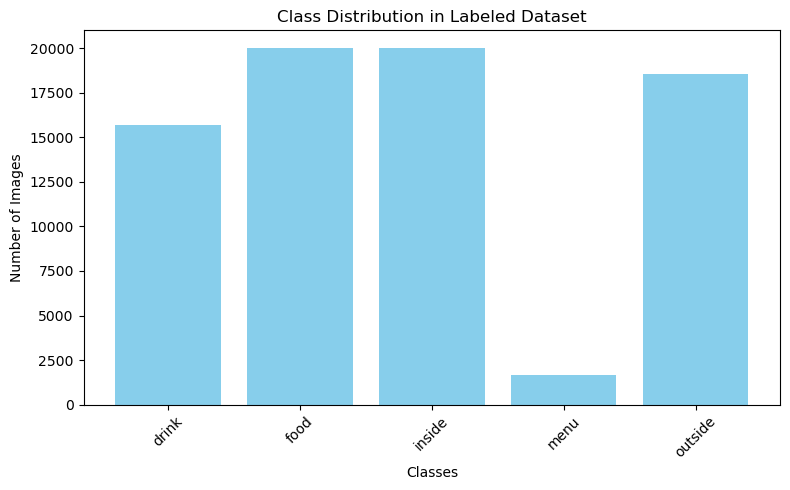

In [73]:
import os
import matplotlib.pyplot as plt

# Path to the balanced labeled dataset
data_dir = './yelp_photos/balanced_labeled_photos'

# Class distribution (number of images per class)
label_counts = {}
for label in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label)
    if os.path.isdir(label_folder):
        label_counts[label] = len(os.listdir(label_folder))

# Plotting the class distribution
labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Class Distribution in Labeled Dataset')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

### Since the augmentation for the menu class didn't go well we will try again to upsample the images

In [76]:
import os
import random
from PIL import Image
import shutil

# Function to augment a single image
def augment_image(image_path, augmented_folder):
    # Open image
    img = Image.open(image_path)
    
    # Apply some augmentations
    # Rotate image randomly between -15 to +15 degrees
    img = img.rotate(random.randint(-15, 15))

    # Flip image randomly
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Random zoom (crop a random section and resize back)
    width, height = img.size
    crop_width = random.randint(int(0.8 * width), width)
    crop_height = random.randint(int(0.8 * height), height)
    img = img.crop((0, 0, crop_width, crop_height)).resize((width, height))

    # Save the augmented image
    augmented_image_path = os.path.join(augmented_folder, os.path.basename(image_path))
    img.save(augmented_image_path)

# Augment class images to reach the target sample count
def augment_class_images(label_name, target_count, source_folder, augmented_folder):
    os.makedirs(augmented_folder, exist_ok=True)
    
    # Load existing images in the class folder
    all_files = os.listdir(source_folder)
    print(f"Augmenting {label_name} class...")

    # We will augment images until we reach the target count
    augmented_files = []
    
    # Augment the original images in 'menu' class
    while len(augmented_files) < target_count:
        for file in all_files:
            image_path = os.path.join(source_folder, file)
            if len(augmented_files) >= target_count:
                break
            augment_image(image_path, augmented_folder)
            augmented_files.append(file)

    print(f"Augmented {label_name} to {len(augmented_files)} samples.")

# Paths
menu_source_folder = os.path.join('./yelp_photos/labeled_photos', 'menu')
augmented_menu_folder = './yelp_photos/balanced_labeled_photos/menu'

# Augment 'menu' class to 20k samples
augment_class_images('menu', 20000, menu_source_folder, augmented_menu_folder)

Augmenting menu class...
Augmented menu to 20000 samples.


In [78]:
menu_folder = './yelp_photos/balanced_labeled_photos/menu'
menu_image_count = len(os.listdir(menu_folder))
print(f"Total images in 'menu' class: {menu_image_count}")

Total images in 'menu' class: 1678


### Since the above approach didn't work we are trying again with below approach :
- Read and augment images: Ensure that images are augmented multiple times and the output folder is used correctly.
- Continue augmentation until target is met: Instead of augmenting once and stopping, we’ll augment each image multiple times to generate more new images.

In [81]:
import os
import random
from PIL import Image
import shutil

# Function to augment a single image
def augment_image(image_path, augmented_folder, img_count):
    # Open image
    img = Image.open(image_path)
    
    # Apply augmentations
    # Rotate image randomly between -15 to +15 degrees
    img = img.rotate(random.randint(-15, 15))

    # Flip image randomly
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Random zoom (crop a random section and resize back)
    width, height = img.size
    crop_width = random.randint(int(0.8 * width), width)
    crop_height = random.randint(int(0.8 * height), height)
    img = img.crop((0, 0, crop_width, crop_height)).resize((width, height))

    # Save the augmented image
    augmented_image_path = os.path.join(augmented_folder, f"augmented_{img_count}.jpg")
    img.save(augmented_image_path)

# Augment class images to reach the target sample count
def augment_class_images(label_name, target_count, source_folder, augmented_folder):
    os.makedirs(augmented_folder, exist_ok=True)
    
    # Load existing images in the class folder
    all_files = os.listdir(source_folder)
    print(f"Original count for {label_name}: {len(all_files)}")
    
    # Calculate how many more images we need to create
    needed_samples = target_count - len(all_files)
    
    print(f"Augmenting {label_name} class to reach {target_count} samples, need {needed_samples} more images.")

    img_count = len(all_files)  # Start counting from original images
    while img_count < target_count:
        for file in all_files:
            if img_count >= target_count:
                break
            image_path = os.path.join(source_folder, file)
            augment_image(image_path, augmented_folder, img_count)
            img_count += 1

    print(f"Augmented {label_name} to {img_count} samples.")

# Paths
menu_source_folder = os.path.join('./yelp_photos/labeled_photos', 'menu')
augmented_menu_folder = './yelp_photos/balanced_labeled_photos/menu'

# Augment 'menu' class to 20k samples (if needed)
augment_class_images('menu', 20000, menu_source_folder, augmented_menu_folder)

# Verify the new image count in the 'menu' class
menu_image_count = len(os.listdir(augmented_menu_folder))
print(f"Total images in 'menu' class after augmentation: {menu_image_count}")

Original count for menu: 1678
Augmenting menu class to reach 20000 samples, need 18322 more images.
Augmented menu to 20000 samples.
Total images in 'menu' class after augmentation: 20000


## Since the menu class augmentation went well now we will plot graphs to see the results and further analysis

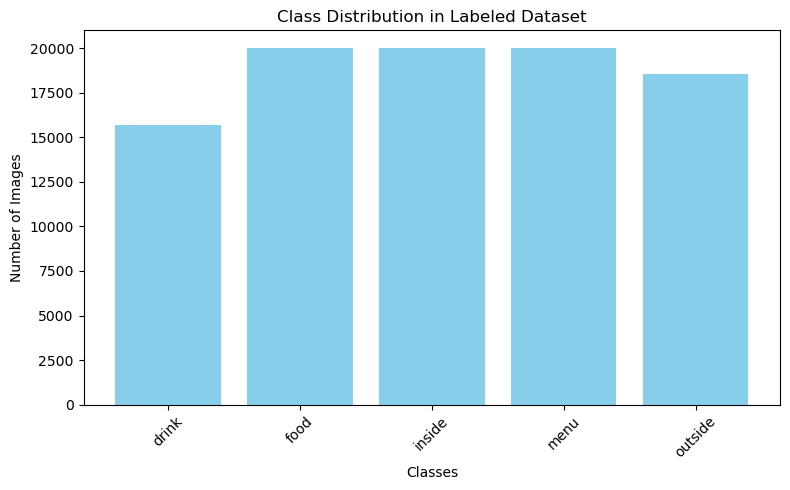

In [84]:
import os
import matplotlib.pyplot as plt

# Path to the balanced labeled dataset
data_dir = './yelp_photos/balanced_labeled_photos'

# Class distribution (number of images per class)
label_counts = {}
for label in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label)
    if os.path.isdir(label_folder):
        label_counts[label] = len(os.listdir(label_folder))

# Plotting the class distribution
labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Class Distribution in Labeled Dataset')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

## Finalizing the EDA and Vizualizing the Data

## Recheck Class Distribution

In [88]:
# Check the updated class distribution
label_counts = {}
for label in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label)
    if os.path.isdir(label_folder):
        label_counts[label] = len(os.listdir(label_folder))

# Display the updated class distribution
for label, count in label_counts.items():
    print(f"Total images in '{label}' class: {count}")

Total images in 'drink' class: 15670
Total images in 'food' class: 20000
Total images in 'inside' class: 20000
Total images in 'menu' class: 20000
Total images in 'outside' class: 18569


## Visualize Sample Images from Each Class.

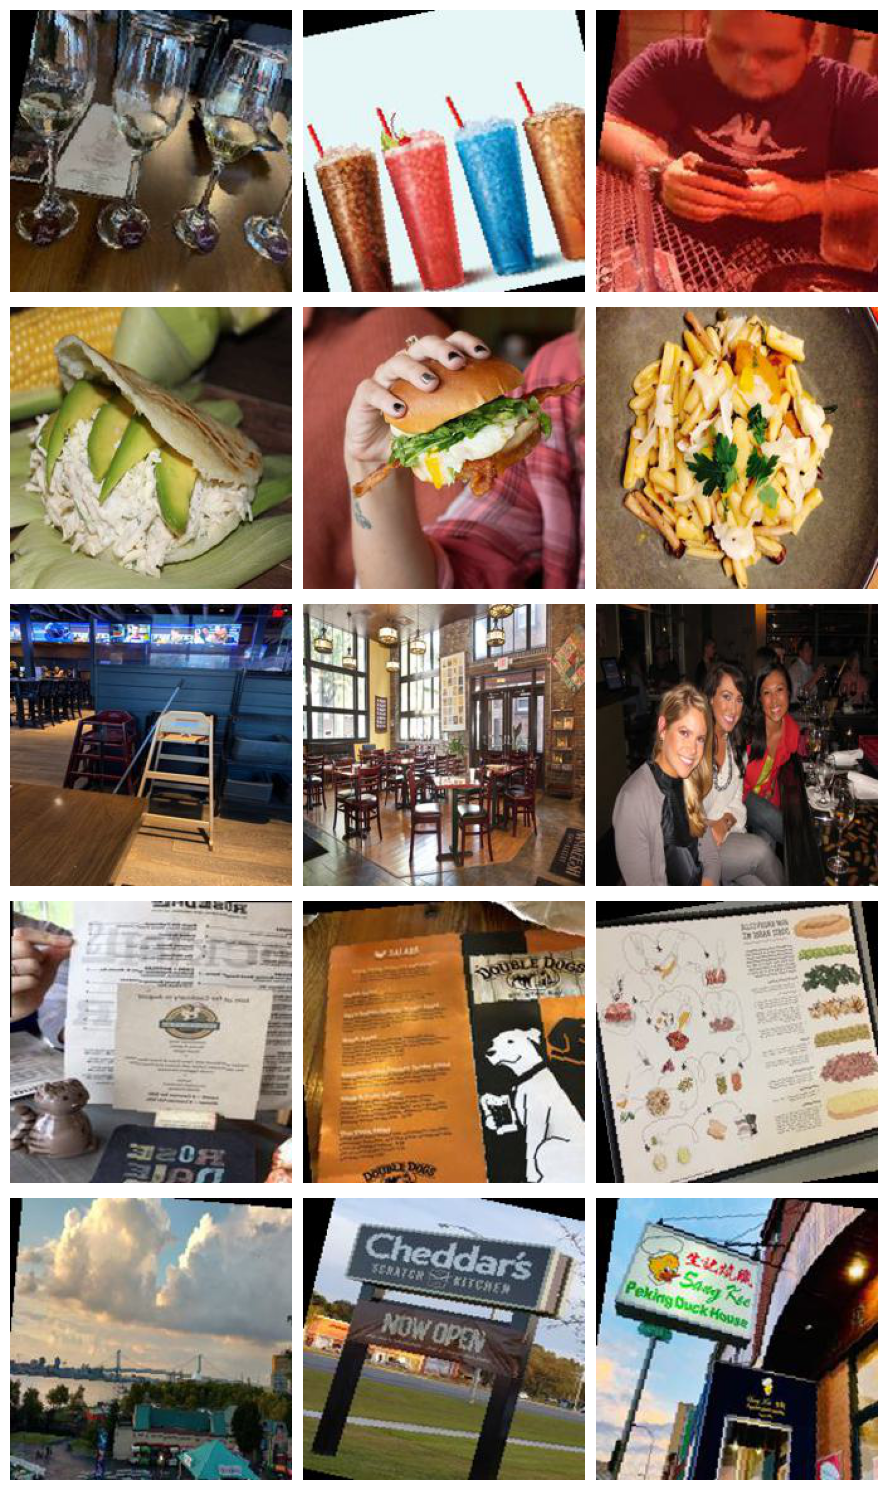

In [93]:
import random
import matplotlib.pyplot as plt
from PIL import Image

samples_per_class = 3
fig, axs = plt.subplots(len(label_counts), samples_per_class, figsize=(samples_per_class*3, len(label_counts)*3))

for i, label in enumerate(label_counts.keys()):
    label_folder = os.path.join(data_dir, label)
    images = random.sample(os.listdir(label_folder), samples_per_class)
    
    for j, img_file in enumerate(images):
        img_path = os.path.join(label_folder, img_file)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].axis('off')
        if j == 0:
            axs[i, j].set_ylabel(label, fontsize=12)
            
plt.tight_layout()
plt.show()

## Image Size Distribution

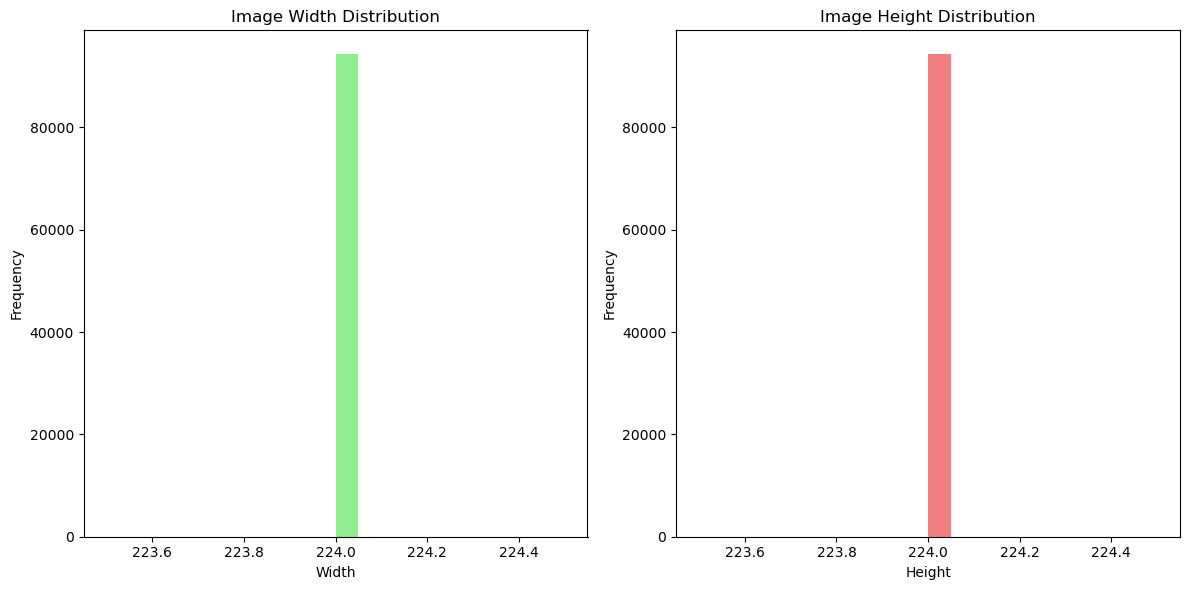

In [96]:
import numpy as np

# Collect image sizes (width, height) from all images
image_sizes = []

for label in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label)
    for img_file in os.listdir(label_folder):
        img_path = os.path.join(label_folder, img_file)
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)  # Store width, height
        except:
            print(f"Could not open {img_path}")

sizes_np = np.array(image_sizes)
widths = sizes_np[:, 0]
heights = sizes_np[:, 1]

# Plotting image size distribution (width and height)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=20, color='lightgreen')
plt.title('Image Width Distribution')
plt.xlabel('Width')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(heights, bins=20, color='lightcoral')
plt.title('Image Height Distribution')
plt.xlabel('Height')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

 ## Average RGB Color Intensity per Class

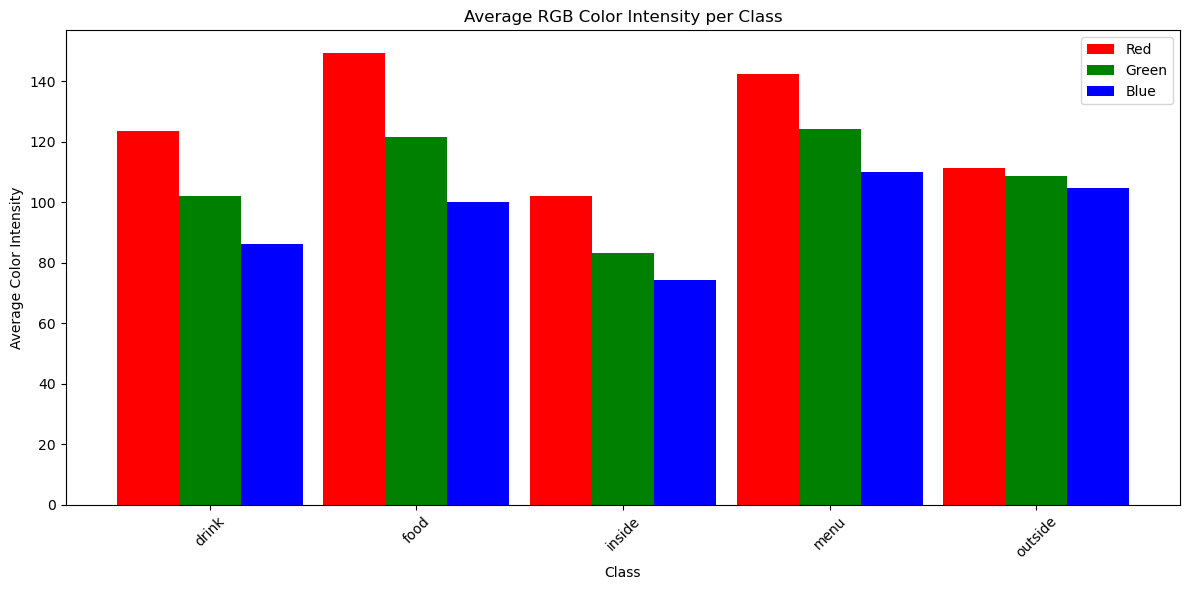

In [98]:
def calculate_average_rgb(image_path):
    img = Image.open(image_path)
    img = img.convert("RGB")
    pixels = np.array(img)
    return np.mean(pixels, axis=(0, 1))  # Mean of all pixels in RGB channels

average_colors = {label: [] for label in label_counts.keys()}

for label in label_counts.keys():
    label_folder = os.path.join(data_dir, label)
    images = os.listdir(label_folder)
    for img_file in images[:100]:  # Take the first 100 images for each class
        img_path = os.path.join(label_folder, img_file)
        avg_rgb = calculate_average_rgb(img_path)
        average_colors[label].append(avg_rgb)

avg_rgb_per_class = {label: np.mean(average_colors[label], axis=0) for label in average_colors}

# Plotting average RGB values for each class
reds = [rgb[0] for rgb in avg_rgb_per_class.values()]
greens = [rgb[1] for rgb in avg_rgb_per_class.values()]
blues = [rgb[2] for rgb in avg_rgb_per_class.values()]

plt.figure(figsize=(12, 6))
bar_width = 0.3
indices = np.arange(len(avg_rgb_per_class))

plt.bar(indices, reds, width=bar_width, label='Red', color='r')
plt.bar(indices + bar_width, greens, width=bar_width, label='Green', color='g')
plt.bar(indices + 2*bar_width, blues, width=bar_width, label='Blue', color='b')

plt.xticks(indices + bar_width, avg_rgb_per_class.keys(), rotation=45)
plt.xlabel('Class')
plt.ylabel('Average Color Intensity')
plt.title('Average RGB Color Intensity per Class')
plt.legend()
plt.tight_layout()
plt.show()

## LLM Prompts
- what are approaches of data augmentation
- what are different approaches of image data classifications how to optimize
- How to check image size distribution
- plot the rgb rgb color intensity with labels